#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
#from predict_loop_functions import predict_loop, noise_iterations 
from predict_loop_functions import filter_region, line_plot_mean, five_turning_curves, spike_plot_4x2, remove_x
from scipy.stats import linregress

In [ ]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [2]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
                    1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [ ]:
d3_sum, d3_mean, d3_var, d3_labels = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [ ]:
d15_sum, d15_mean, d15_var, d15_labels = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [6]:
d30_sum, d30_mean, d30_var, d30_labels = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [7]:
c3_sum, c3_mean, c3_var, c3_labels = predict_loop('constant', image_stack, 3, [[4,7]])

In [8]:
c15_sum, c15_mean, c15_var, c15_labels = predict_loop('constant', image_stack, 15, [[4,7]])

In [9]:
c30_sum, c30_mean, c30_var, c30_labels = predict_loop('constant', image_stack, 30, [[4,7]])

In [10]:
dbin_sum, dbin_mean, dbin_var, dbin_labels = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [11]:
cbin_sum, cbin_mean, cbin_var, cbin_labels = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [34]:
# save predictions to predictions_july21
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type_output in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_output
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

##### add no noise prediction for turning curves

In [ ]:
no_noise_sum, no_noise_mean, no_noise_var, no_noise_labels = predict_loop('no noise', image_stack, 0, [[4,7]])

In [14]:
for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = 'no_noise' + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions

In [3]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_noise + '.npy'
        var_name = noise + type_noise
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [4]:
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = noise + type_noise + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type_noise + '_r' + str(region)
            globals()[array_name] = np.load(path)

#### filtering by region (function completed)

In [5]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_output in ['_sum', '_mean', '_var']:
        for i in np.unique(d3_labels): # use first prediction array to get possible regions 
            print(f'noise {noise}, type output {type_output}, label {i}')
            filtered_array = filter_region(i, globals()[noise+'_labels'], globals()[noise+type_output])
            file_name = noise+type_output+'_r'+str(i)
            #globals()[filtered_array] = 
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            np.save(path, arr = filtered_array)

noise c3, type output _sum, label 1
noise c3, type output _sum, label 2
noise c3, type output _sum, label 3
noise c3, type output _sum, label 4
noise c3, type output _mean, label 1
noise c3, type output _mean, label 2
noise c3, type output _mean, label 3
noise c3, type output _mean, label 4
noise c3, type output _var, label 1
noise c3, type output _var, label 2
noise c3, type output _var, label 3
noise c3, type output _var, label 4
noise c15, type output _sum, label 1
noise c15, type output _sum, label 2
noise c15, type output _sum, label 3
noise c15, type output _sum, label 4
noise c15, type output _mean, label 1
noise c15, type output _mean, label 2
noise c15, type output _mean, label 3
noise c15, type output _mean, label 4
noise c15, type output _var, label 1
noise c15, type output _var, label 2
noise c15, type output _var, label 3
noise c15, type output _var, label 4
noise c30, type output _sum, label 1
noise c30, type output _sum, label 2
noise c30, type output _sum, label 3
noise

#### filter function fix

In [15]:
test1, test2, test3, test_labels = predict_loop('no noise', image_stack, 0, [[4,7]], noise_seeds = 3, num_frames = 2)

In [16]:
type(test_labels[0])

pandas.core.series.Series

In [17]:
test_labels_flat = np.array(test_labels[0]).flatten()

In [6]:
type(test_labels_flat)

numpy.ndarray

In [7]:
for x in test_labels_flat: 
    if not (type(x) != int): print(x)

In [18]:
test1_r2 = filter_region(2, test_labels_flat, test1)

In [19]:
test1_r2.shape

(5, 3, 983)

In [20]:
pd.DataFrame(test_labels).T.value_counts()

brain_area
1             5312
2              983
4              811
3              387
Name: count, dtype: int64

#### line plotting data for image 0 (gray frames), mean

Region 1

In [4]:
# region 1 dynamic, plotting data
plot_mean_d30_r1 = line_plot_mean(d30_mean_r1, [i for i in range(100)], 0)
plot_mean_d15_r1 = line_plot_mean(d15_mean_r1, [i for i in range(100)], 0)
plot_mean_d3_r1 = line_plot_mean(d3_mean_r1, [i for i in range(100)], 0)
plot_mean_dbin_r1 = line_plot_mean(dbin_mean_r1, [i for i in range(100)], 0)

In [5]:
# region 1 constant, plotting data
plot_mean_c30_r1 = line_plot_mean(c30_mean_r1, [i for i in range(100)], 0)
plot_mean_c15_r1 = line_plot_mean(c15_mean_r1, [i for i in range(100)], 0)
plot_mean_c3_r1 = line_plot_mean(c3_mean_r1, [i for i in range(100)], 0)
plot_mean_cbin_r1 = line_plot_mean(cbin_mean_r1, [i for i in range(100)], 0)

Region 2

In [6]:
# region 2 dynamic, plotting data
plot_mean_d30_r2 = line_plot_mean(d30_mean_r2, [i for i in range(100)], 0)
plot_mean_d15_r2 = line_plot_mean(d15_mean_r2, [i for i in range(100)], 0)
plot_mean_d3_r2 = line_plot_mean(d3_mean_r2, [i for i in range(100)], 0)
plot_mean_dbin_r2 = line_plot_mean(dbin_mean_r2, [i for i in range(100)], 0)

In [7]:
# region 2 constant, plotting data
plot_mean_c30_r2 = line_plot_mean(c30_mean_r2, [i for i in range(100)], 0)
plot_mean_c15_r2 = line_plot_mean(c15_mean_r2, [i for i in range(100)], 0)
plot_mean_c3_r2 = line_plot_mean(c3_mean_r2, [i for i in range(100)], 0)
plot_mean_cbin_r2 = line_plot_mean(cbin_mean_r2, [i for i in range(100)], 0)

Region 3

In [8]:
# region 3 dynamic, plotting data
plot_mean_d30_r3 = line_plot_mean(d30_mean_r3, [i for i in range(100)], 0)
plot_mean_d15_r3 = line_plot_mean(d15_mean_r3, [i for i in range(100)], 0)
plot_mean_d3_r3 = line_plot_mean(d3_mean_r3, [i for i in range(100)], 0)
plot_mean_dbin_r3 = line_plot_mean(dbin_mean_r3, [i for i in range(100)], 0)

In [9]:
# region 3 constant, plotting data
plot_mean_c30_r3 = line_plot_mean(c30_mean_r3, [i for i in range(100)], 0)
plot_mean_c15_r3 = line_plot_mean(c15_mean_r3, [i for i in range(100)], 0)
plot_mean_c3_r3 = line_plot_mean(c3_mean_r3, [i for i in range(100)], 0)
plot_mean_cbin_r3 = line_plot_mean(cbin_mean_r3, [i for i in range(100)], 0)

Region 4

In [10]:
# region 4 dynamic, plotting data
plot_mean_d30_r4 = line_plot_mean(d30_mean_r4, [i for i in range(100)], 0)
plot_mean_d15_r4 = line_plot_mean(d15_mean_r4, [i for i in range(100)], 0)
plot_mean_d3_r4 = line_plot_mean(d3_mean_r4, [i for i in range(100)], 0)
plot_mean_dbin_r4 = line_plot_mean(dbin_mean_r4, [i for i in range(100)], 0)

In [11]:
# region 4 constant, plotting data
plot_mean_c30_r4 = line_plot_mean(c30_mean_r4, [i for i in range(100)], 0)
plot_mean_c15_r4 = line_plot_mean(c15_mean_r4, [i for i in range(100)], 0)
plot_mean_c3_r4 = line_plot_mean(c3_mean_r4, [i for i in range(100)], 0)
plot_mean_cbin_r4 = line_plot_mean(cbin_mean_r4, [i for i in range(100)], 0)

##### region 1

In [29]:
dynamic_arrays_r1 = [plot_mean_d3_r1, plot_mean_d15_r1, plot_mean_d30_r1, plot_mean_dbin_r1]
constant_arrays_r1 = [plot_mean_c3_r1, plot_mean_c15_r1, plot_mean_c30_r1, plot_mean_cbin_r1]

make one 4x2 plot for raw and one for normalized.
> columns will be dynamic and constant

> each row is region

In [ ]:
def spike_plot(dynamic_array: list, constant_array: list, mean_plot: bool,
               normalized: bool, region: int, sigmas: list = [3, 15, 30], num_neurons: int = 100):
    """
    Parameters
    ----------
    dynamic_array: list
        list of dynamic noise mean/var arrays from prediction loop
    constant_array: list
        list of constant noise mean/var arrays from prediction loop
    mean_plot: bool
        if plot is for mean values or not (variance plot)
    normalized: bool
        to normalize values or not
    region: int
        input region from brain for title
    sigmas: list
        defaults to list of sigma values for noise used for initial runs
    num_neurons: int
        number of neurons to plot, defaults to 100
    
    Returns
    -------
    matplotlib plot
        line plot of sigma versus mean or var spike counts
    """
    fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

    sigmas = np.array([3, 15, 30])

    colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

    dynamic_means_y = np.empty((num_neurons, len(sigmas)))
    constant_means_y = np.empty((num_neurons, len(sigmas)))

    for i in range(num_neurons):
        dynamic_y = np.array([dynamic_array[0][i], dynamic_array[1][i], dynamic_array[2][i]]) / dynamic_array[0][i] if normalized else np.array(
            [dynamic_array[0][i], dynamic_array[1][i], dynamic_array[2][i]])
        constant_y = np.array([constant_array[0][i], constant_array[1][i], constant_array[2][i]]) / constant_array[0][i] if normalized else np.array(
            [constant_array[0][i], constant_array[1][i], constant_array[2][i]])

        axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

        axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
        
        dynamic_means_y[i] = dynamic_y
        constant_means_y[i] = constant_y

    dynamic_mean_plot = np.mean(dynamic_means_y, axis = 0) / np.mean(dynamic_means_y[0], axis = 0) if normalized else np.mean(dynamic_means_y, axis = 0)
    constant_mean_plot = np.mean(dynamic_means_y, axis=0) / np.mean(constant_means_y[0], axis=0) if normalized else np.mean(constant_means_y, axis = 0)

    slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_plot)
    y_pred_dyn = intercept_dyn + slope_dyn * sigmas
    slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_plot)
    y_pred_con = intercept_con + slope_con * sigmas


    axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

    axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

    # error band/SE
    dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
    con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
    axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
    axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

    print(f'\033[1m\033[4mDynamic Noise 95% Confidence Interval for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]')
    print(f'\033[4m\033[1mConstant Noise 95% Confidence Interval for Slope: [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]')
    
    if not normalized: 
        axes[0].text(2, axes[0].get_ylim()[1]-4.5, f'Slope: {slope_dyn:.3f}')
        axes[1].text(2, axes[1].get_ylim()[1]-4.5, f'Slope: {slope_con:.3f}')

    axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
    axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
    axes[0].set_xlabel('Sigma for Input Noise')
    axes[0].set_title(f'Dynamic Noise ({num_neurons} neurons, Region={region})\nNormalized by Response at Sigma=3' if normalized 
                    else f'Dynamic Noise ({num_neurons} neurons, Region={region})', fontsize = 11)
    axes[1].set_title(f'Constant Noise (100 neurons, Region={region})\nNormalized by Response at Sigma=3' if normalized
                      else f'Constant Noise (100 neurons, Region={region})', fontsize = 11)
    axes[0].set_ylabel('Mean Prediction\nSpike Count' if mean_plot else 'Variance in\nPredicted Spike Count')
    axes[1].set_xlabel('Sigma for Input Noise')
    axes[0].legend(loc='upper left')
    axes[1].legend(loc='upper left')
    plt.tight_layout()
    plt.show()

Dynamic Noise 95% Confidence Interval for Slope: [0.006, 0.061]
Constant Noise 95% Confidence Interval for Slope: [0.031, 0.068]


C:\Users\joshf\AppData\Local\Temp\ipykernel_23784\2121527931.py:57: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_23784\2121527931.py:59: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


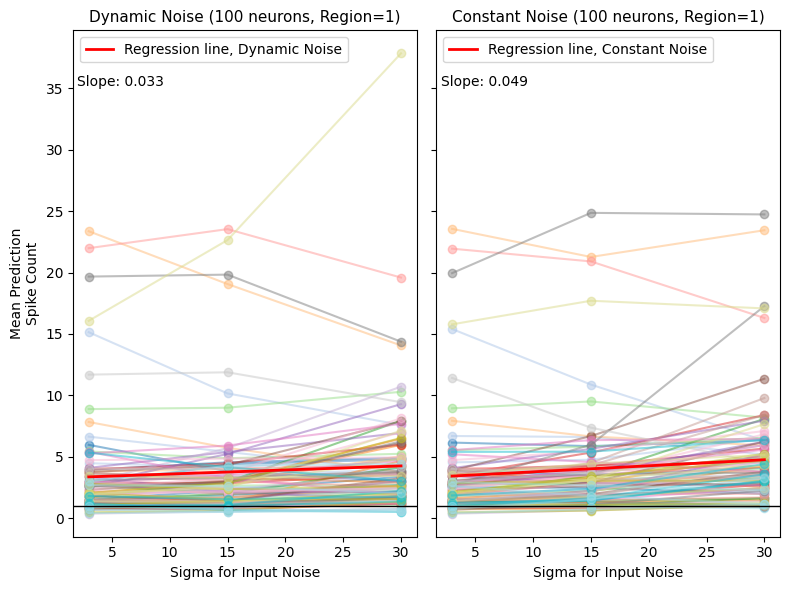

In [42]:
spike_plot(dynamic_arrays_r1, constant_arrays_r1, True, False, 1)

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.026]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.033]


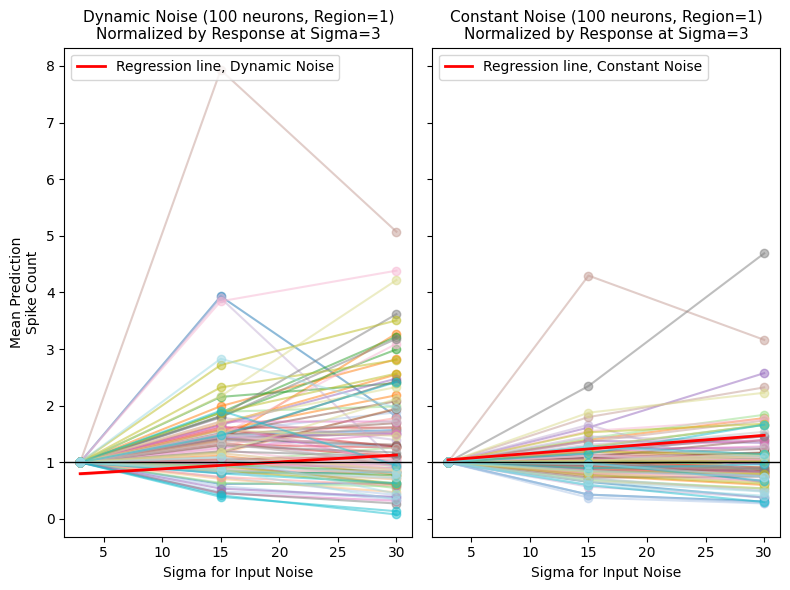

In [21]:
spike_plot(dynamic_arrays_r1, constant_arrays_r1, True, True, 1)

region 2

In [22]:
dynamic_arrays_r2 = [plot_mean_d3_r2, plot_mean_d15_r2, plot_mean_d30_r2]
constant_arrays_r2 = [plot_mean_c3_r2, plot_mean_c15_r2, plot_mean_c30_r2]

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.114, 0.293]
Constant Noise 95% Confidence Interval for Slope: [-0.039, -0.010]


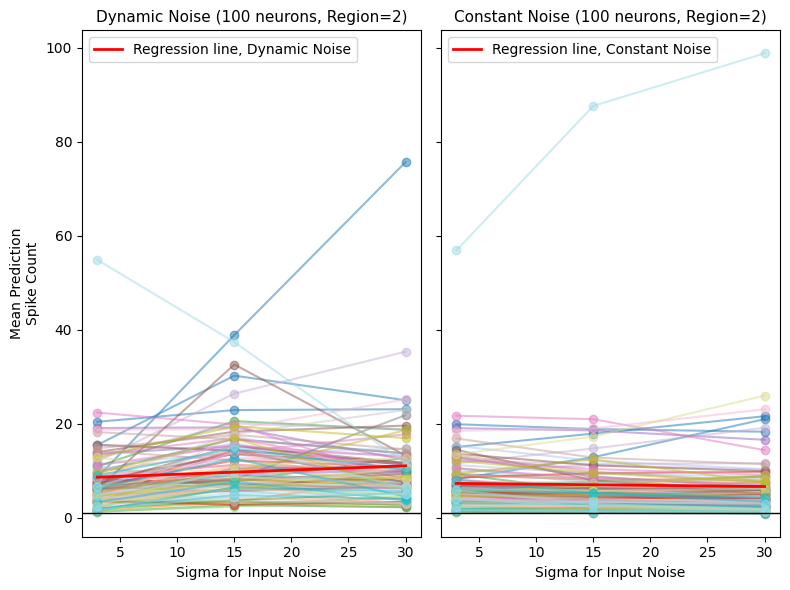

In [23]:
spike_plot(dynamic_arrays_r2, constant_arrays_r2, True, False, 2)

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.009, 0.059]
Constant Noise 95% Confidence Interval for Slope: [-0.010, 0.067]


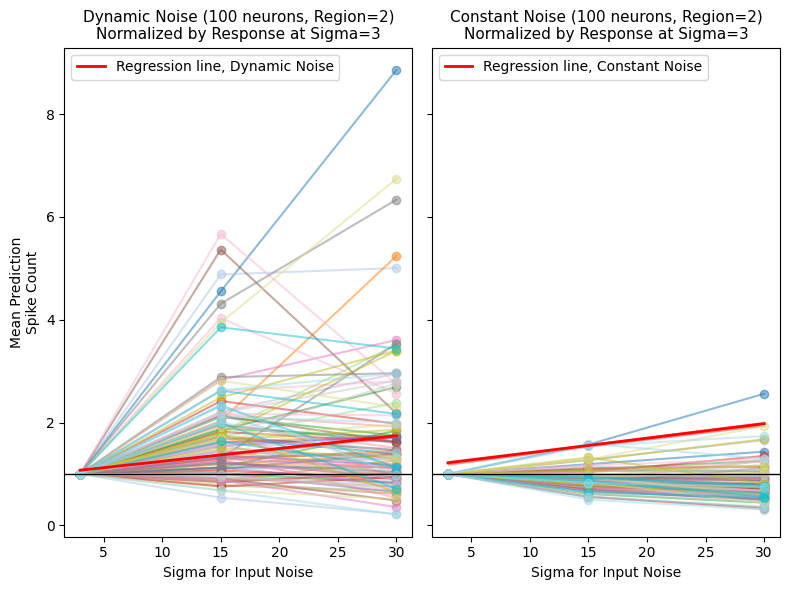

In [26]:
spike_plot(dynamic_arrays_r2, constant_arrays_r2, True, True, 2)

region 3

In [27]:
dynamic_arrays_r3 = [plot_mean_d3_r3, plot_mean_d15_r3, plot_mean_d30_r3]
constant_arrays_r3 = [plot_mean_c3_r3, plot_mean_c15_r3, plot_mean_c30_r3]

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.070, -0.049]
Constant Noise 95% Confidence Interval for Slope: [-0.113, -0.041]


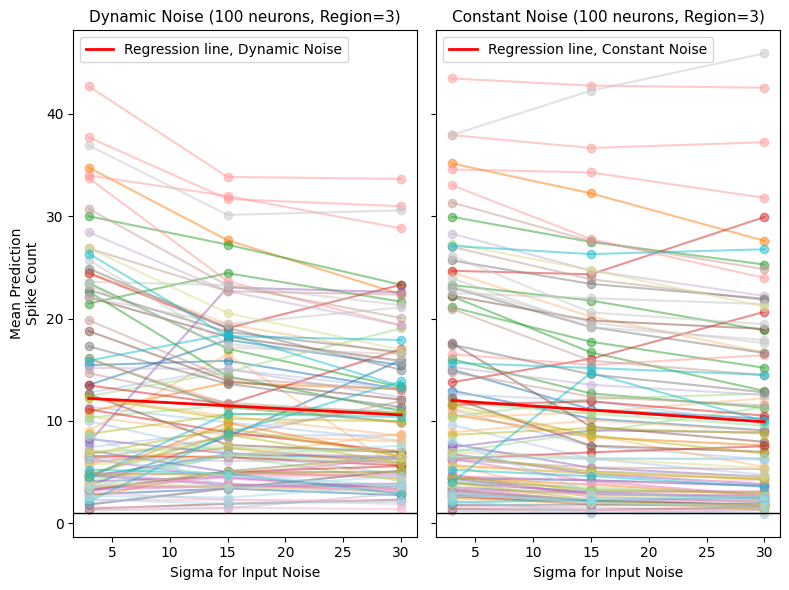

In [29]:
spike_plot(dynamic_arrays_r3, constant_arrays_r3, True, False, 3)

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.000, 0.008]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.011]


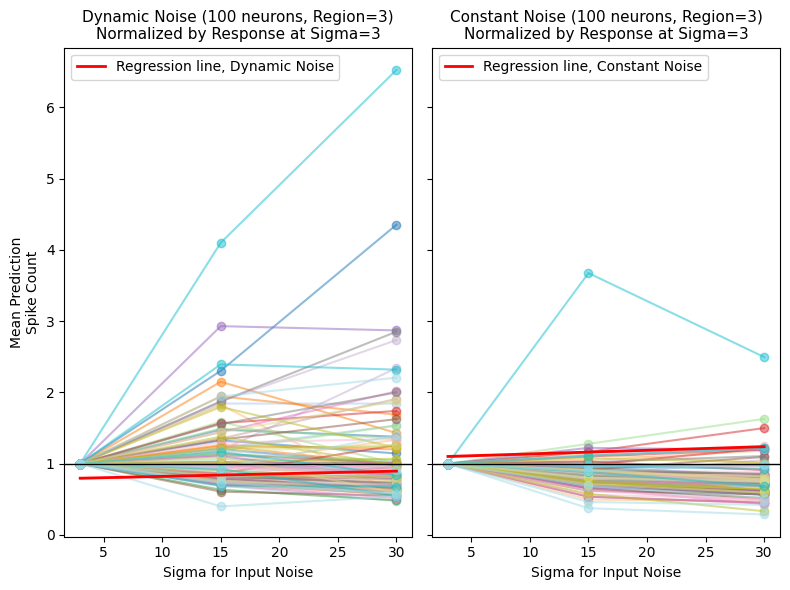

In [30]:
spike_plot(dynamic_arrays_r3, constant_arrays_r3, True, True, 3)

region 4

In [31]:
dynamic_arrays_r4 = [plot_mean_d3_r4, plot_mean_d15_r4, plot_mean_d30_r4]
constant_arrays_r4 = [plot_mean_c3_r4, plot_mean_c15_r4, plot_mean_c30_r4]

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.065, -0.012]
Constant Noise 95% Confidence Interval for Slope: [-0.019, -0.004]


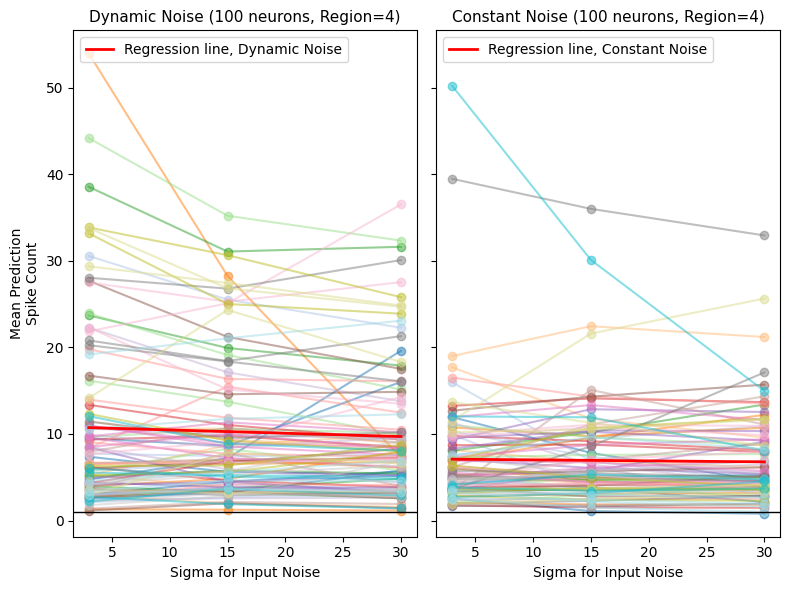

In [32]:
spike_plot(dynamic_arrays_r4, constant_arrays_r1, True, False, 4)

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [0.002, 0.004]
Constant Noise 95% Confidence Interval for Slope: [0.002, 0.006]


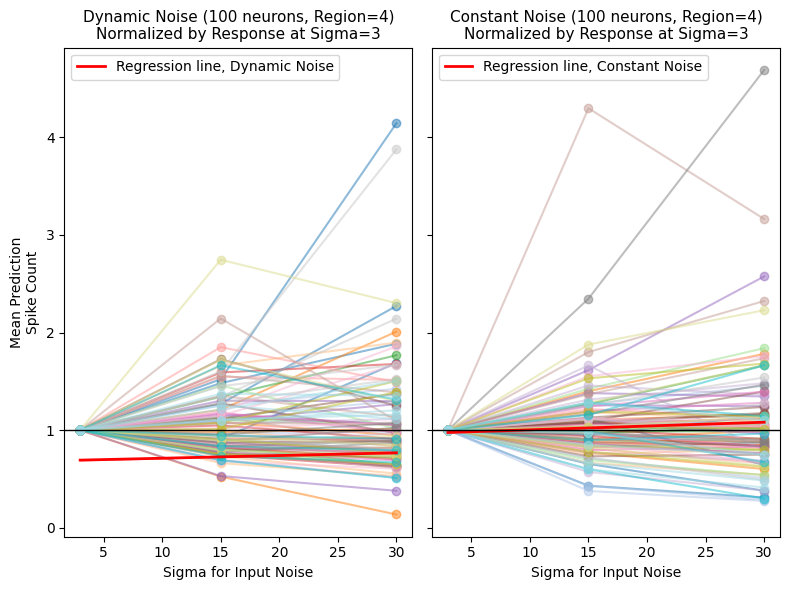

In [33]:
spike_plot(dynamic_arrays_r4, constant_arrays_r1, True, True, 4)

##### region 1

In [16]:
dynamic_means_r1 = [plot_mean_d3_r1, plot_mean_d15_r1, plot_mean_d30_r1] 
constant_means_r1 = [plot_mean_c3_r1, plot_mean_c15_r1, plot_mean_c30_r1]

shape of dynamic_mean_plot (3,)
shapes: sigmas(list) 3, constant_mean_plot (3,)
Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.026]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.033]


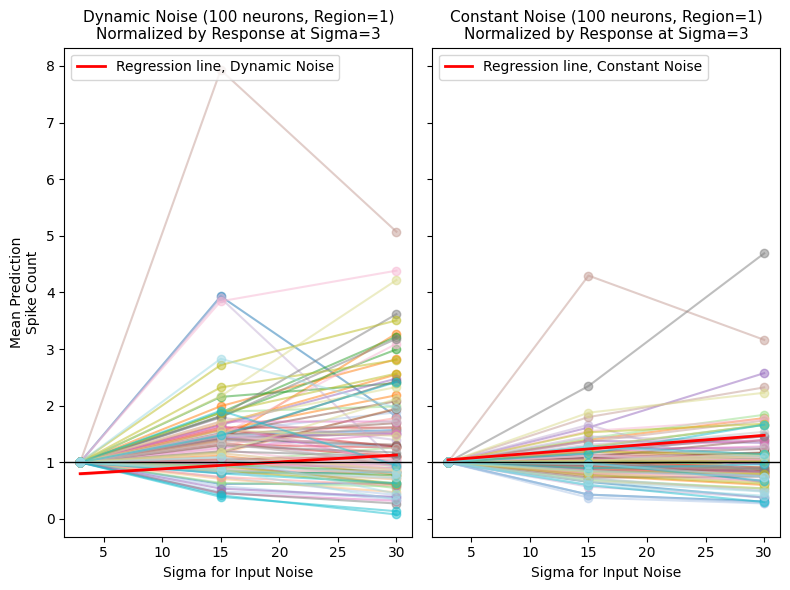

In [17]:
spike_plot(dynamic_means_r1, constant_means_r1,True, True, 1)

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.001, 0.007]
Constant Noise 95% Confidence Interval for Slope: [-0.001, 0.009


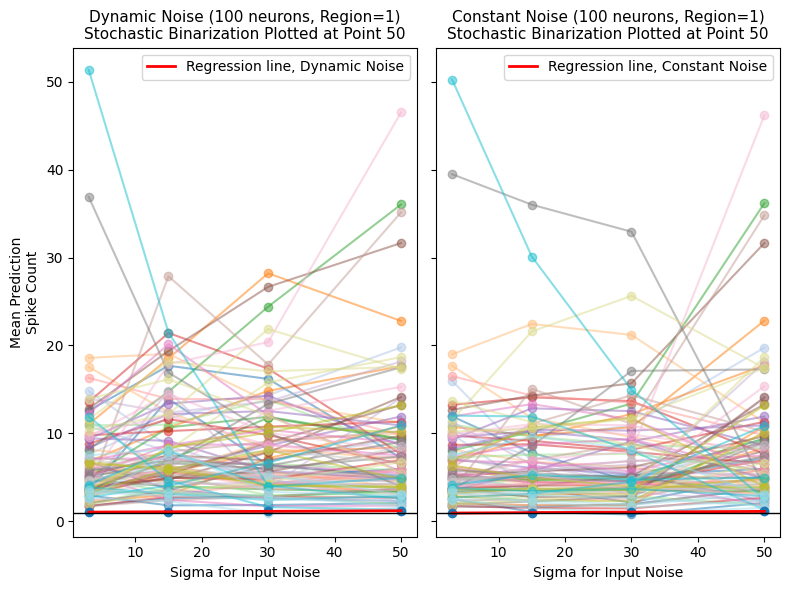

In [38]:
spike_plot(dynamic_means, constant_means, False, 1)

#### 4x2 spike plot - mean

In [29]:
dynamic_arrays_test = [[plot_mean_d3_r1, plot_mean_d15_r1, plot_mean_d30_r1],
                       [plot_mean_d3_r2, plot_mean_d15_r2, plot_mean_d30_r2],
                       [plot_mean_d3_r3, plot_mean_d15_r3, plot_mean_d30_r3],
                       [plot_mean_d3_r4, plot_mean_d15_r4, plot_mean_d30_r4]]

In [30]:
constant_arrays_test = [[plot_mean_c3_r1, plot_mean_c15_r1, plot_mean_c30_r1],
                        [plot_mean_c3_r2, plot_mean_c15_r2, plot_mean_c30_r2],
                        [plot_mean_c3_r3, plot_mean_c15_r3, plot_mean_c30_r3],
                        [plot_mean_c3_r4, plot_mean_c15_r4, plot_mean_c30_r4]]

Region 0, Dynamic Noise 95% CI for Slope: [0.006, 0.061]
Region 0, Constant Noise 95% CI for Slope: [0.031, 0.068]
Region 1, Dynamic Noise 95% CI for Slope: [0.055, 0.105]
Region 1, Constant Noise 95% CI for Slope: [-0.026, -0.000]
Region 2, Dynamic Noise 95% CI for Slope: [-0.090, -0.030]
Region 2, Constant Noise 95% CI for Slope: [-0.134, -0.076]
Region 3, Dynamic Noise 95% CI for Slope: [-0.054, 0.019]
Region 3, Constant Noise 95% CI for Slope: [-0.110, -0.087]


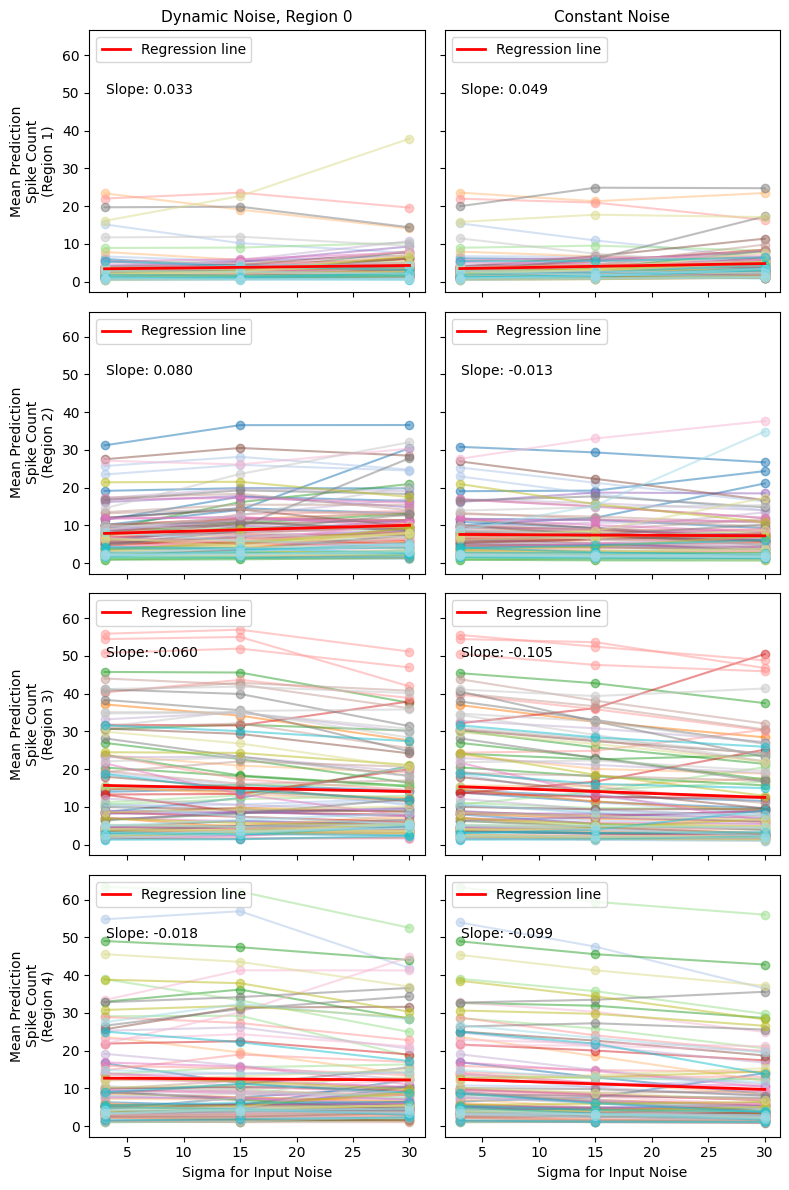

In [32]:
spike_plot_4x2(dynamic_arrays_test, constant_arrays_test, True, False)

Region 0, Dynamic Noise 95% CI for Slope: [0.006, 0.061]
Region 0, Constant Noise 95% CI for Slope: [0.031, 0.068]
Region 1, Dynamic Noise 95% CI for Slope: [0.055, 0.105]
Region 1, Constant Noise 95% CI for Slope: [-0.026, -0.000]
Region 2, Dynamic Noise 95% CI for Slope: [-0.090, -0.030]
Region 2, Constant Noise 95% CI for Slope: [-0.134, -0.076]
Region 3, Dynamic Noise 95% CI for Slope: [-0.054, 0.019]
Region 3, Constant Noise 95% CI for Slope: [-0.110, -0.087]


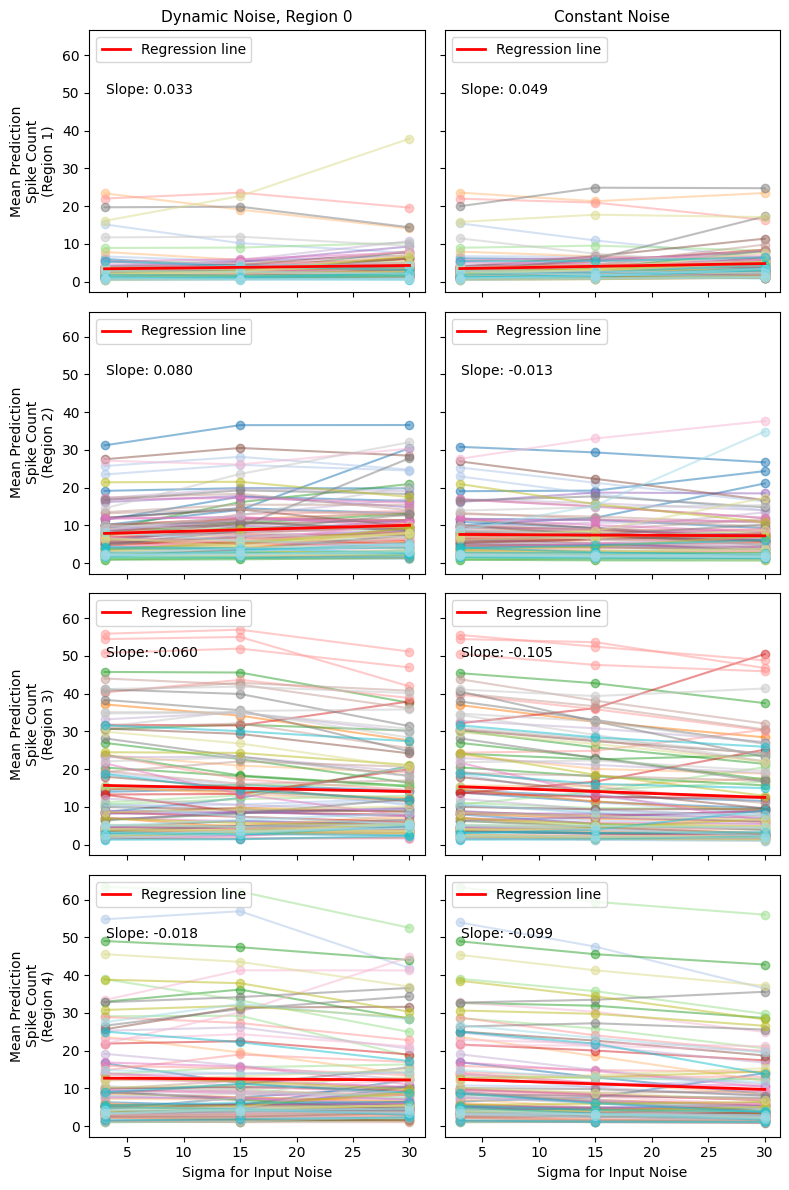

In [15]:
spike_plot_4x2(dynamic_arrays_test, constant_arrays_test, True, False)

#### sigma versus variance

#### new remove top/bottom % function

In [ ]:
def remove_x(arr, remove: str, k_percent: int):
    if len(arr) <= 1:
        return np.arange(len(arr))  
        
    n_remove = int(k_percent / 100 * len(arr))
    n_keep = max(1, len(arr) - n_remove)
    
    if remove == 'top':
        return arr[:n_keep]
    else:  # remove == 'bottom'
        return arr[-n_keep:]

In [26]:
lst = np.array([10,20,30,40,50])

In [27]:
test = remove_x(lst, 'top', 20)

In [28]:
test

array([10, 20, 30, 40])

In [102]:
np.take_along_axis(np.array(lst), test, axis = 0)

array([10, 20, 30, 40])

eliminiating outliers for variance within each region

#### formatting var data for plot

region 1

In [5]:
plot_var_d30_r1 = line_plot_mean(d30_var_r1, [i for i in range(100)], 0)
plot_var_d15_r1 = line_plot_mean(d15_var_r1, [i for i in range(100)], 0)
plot_var_d3_r1 = line_plot_mean(d3_var_r1, [i for i in range(100)], 0)
plot_var_dbin_r1 = line_plot_mean(dbin_var_r1, [i for i in range(100)], 0)

In [6]:
plot_var_c30_r1 = line_plot_mean(c30_var_r1, [i for i in range(100)], 0)
plot_var_c15_r1 = line_plot_mean(c15_var_r1, [i for i in range(100)], 0)
plot_var_c3_r1 = line_plot_mean(c3_var_r1, [i for i in range(100)], 0)
plot_var_cbin_r1 = line_plot_mean(cbin_var_r1, [i for i in range(100)], 0)

region 2

In [7]:
plot_var_d30_r2 = line_plot_mean(d30_var_r2, [i for i in range(100)], 0)
plot_var_d15_r2 = line_plot_mean(d15_var_r2, [i for i in range(100)], 0)
plot_var_d3_r2 = line_plot_mean(d3_var_r2, [i for i in range(100)], 0)
plot_var_dbin_r2 = line_plot_mean(dbin_var_r2, [i for i in range(100)], 0)

In [8]:
plot_var_c30_r2 = line_plot_mean(c30_var_r2, [i for i in range(100)], 0)
plot_var_c15_r2 = line_plot_mean(c15_var_r2, [i for i in range(100)], 0)
plot_var_c3_r2 = line_plot_mean(c3_var_r2, [i for i in range(100)], 0)
plot_var_cbin_r2 = line_plot_mean(cbin_var_r2, [i for i in range(100)], 0)

region 3

In [9]:
plot_var_d30_r3 = line_plot_mean(d30_var_r3, [i for i in range(100)], 0)
plot_var_d15_r3 = line_plot_mean(d15_var_r3, [i for i in range(100)], 0)
plot_var_d3_r3 = line_plot_mean(d3_var_r3, [i for i in range(100)], 0)
plot_var_dbin_r3 = line_plot_mean(dbin_var_r3, [i for i in range(100)], 0)

In [10]:
plot_var_c30_r3 = line_plot_mean(c30_var_r3, [i for i in range(100)], 0)
plot_var_c15_r3 = line_plot_mean(c15_var_r3, [i for i in range(100)], 0)
plot_var_c3_r3 = line_plot_mean(c3_var_r3, [i for i in range(100)], 0)
plot_var_cbin_r3 = line_plot_mean(cbin_var_r3, [i for i in range(100)], 0)

region 4

In [11]:
plot_var_d30_r4 = line_plot_mean(d30_var_r4, [i for i in range(100)], 0)
plot_var_d15_r4 = line_plot_mean(d15_var_r4, [i for i in range(100)], 0)
plot_var_d3_r4 = line_plot_mean(d3_var_r4, [i for i in range(100)], 0)
plot_var_dbin_r4 = line_plot_mean(dbin_var_r4, [i for i in range(100)], 0)

In [12]:
plot_var_c30_r4 = line_plot_mean(c30_var_r4, [i for i in range(100)], 0)
plot_var_c15_r4 = line_plot_mean(c15_var_r4, [i for i in range(100)], 0)
plot_var_c3_r4 = line_plot_mean(c3_var_r4, [i for i in range(100)], 0)
plot_var_cbin_r4 = line_plot_mean(cbin_var_r4, [i for i in range(100)], 0)

#### non-normalized

region 1

In [55]:
dynamic_arrays_r1_var = [plot_var_d3_r1, plot_var_d15_r1, plot_var_d30_r1, plot_var_dbin_r1]
constant_arrays_r1_var = [plot_var_c3_r1, plot_var_c15_r1, plot_var_c30_r1, plot_var_cbin_r1]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.007, 4.014]
Constant Noise 95% Confidence Interval for Slope: [0.255, 1.007


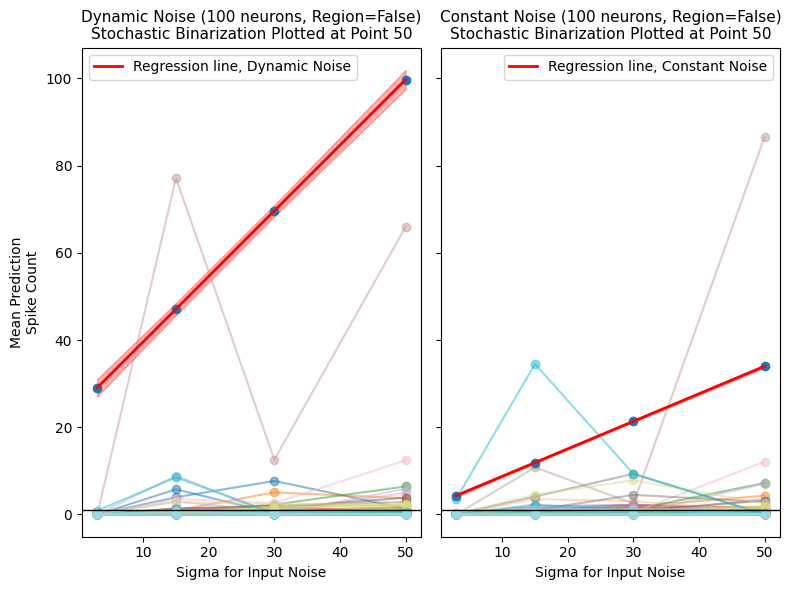

In [56]:
spike_plot(dynamic_arrays_r1_var, constant_arrays_r1_var, False, False, 1)

region 2

In [57]:
dynamic_arrays_r2_var = [plot_var_d3_r2, plot_var_d15_r2, plot_var_d30_r2, plot_var_dbin_r2]
constant_arrays_r2_var = [plot_var_c3_r2, plot_var_c15_r2, plot_var_c30_r2, plot_var_cbin_r2]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.936, 4.689]
Constant Noise 95% Confidence Interval for Slope: [-1.546, 3.482


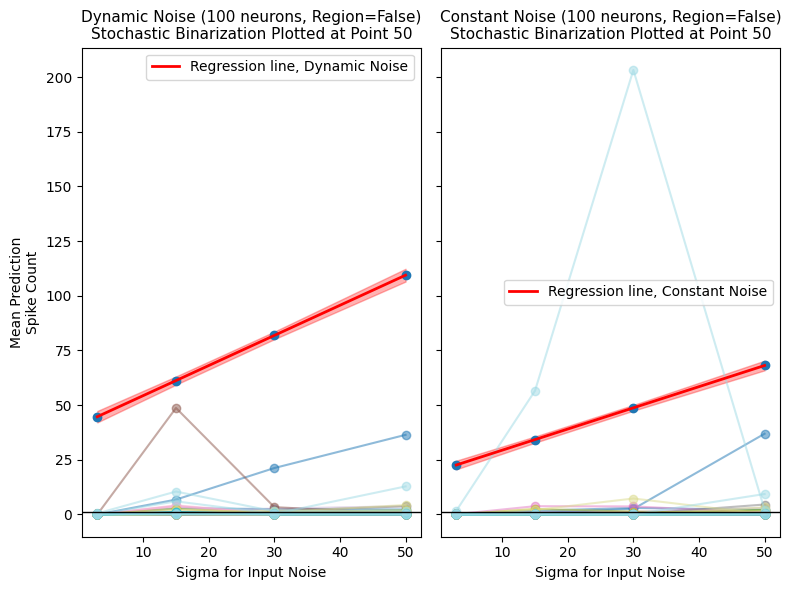

In [58]:
spike_plot(dynamic_arrays_r2_var, constant_arrays_r2_var, False, False, 2)

region 3

In [59]:
dynamic_arrays_r3_var = [plot_var_d3_r3, plot_var_d15_r3, plot_var_d30_r3, plot_var_dbin_r3]
constant_arrays_r3_var = [plot_var_c3_r3, plot_var_c15_r3, plot_var_c30_r3, plot_var_cbin_r3]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [1.148, 3.847]
Constant Noise 95% Confidence Interval for Slope: [0.558, 2.250


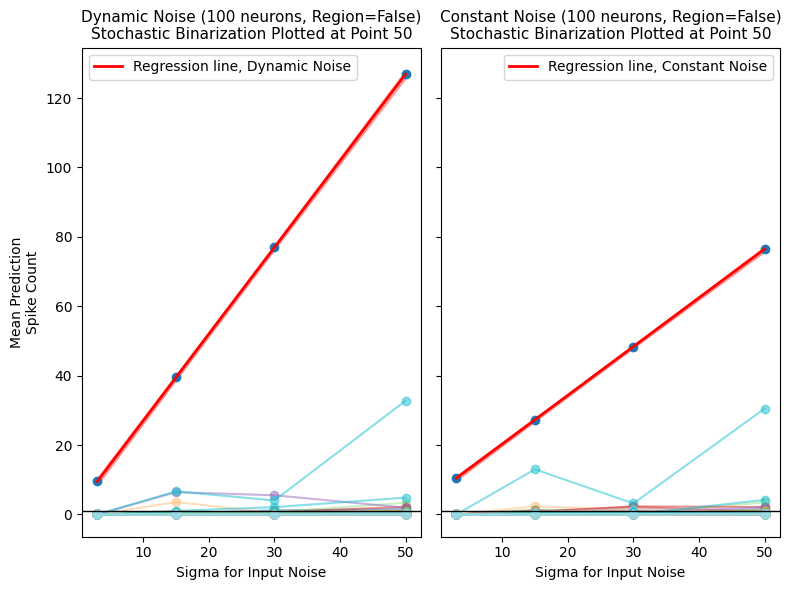

In [60]:
spike_plot(dynamic_arrays_r3_var, constant_arrays_r3_var, False, False, 3)

region 4

In [61]:
dynamic_arrays_r4_var = [plot_var_d3_r4, plot_var_d15_r4, plot_var_d30_r4, plot_var_dbin_r4]
constant_arrays_r4_var = [plot_var_c3_r4, plot_var_c15_r4, plot_var_c30_r4, plot_var_cbin_r4]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.023, 1.084]
Constant Noise 95% Confidence Interval for Slope: [0.307, 0.795


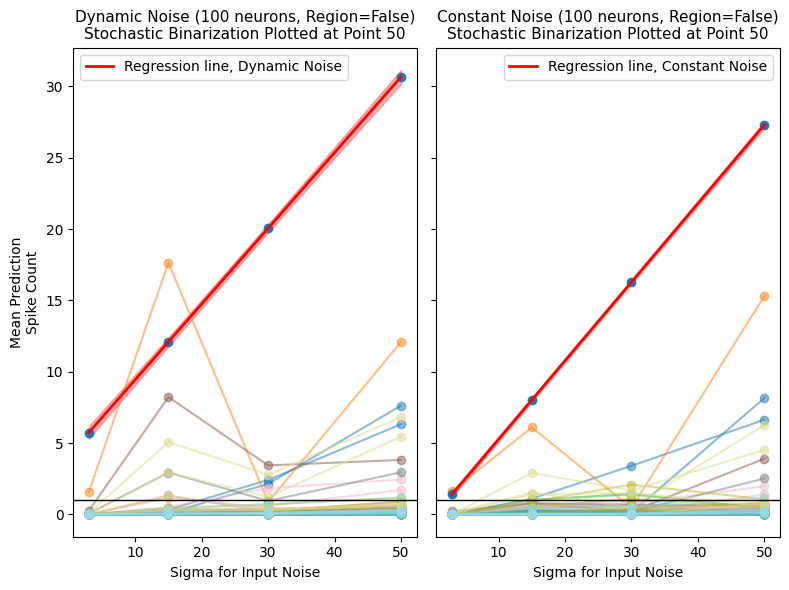

In [62]:
spike_plot(dynamic_arrays_r4_var, constant_arrays_r4_var, False, False, 4)

#### normalized

region 1

In [63]:
dynamic_arrays_r1_var = [plot_var_d3_r1, plot_var_d15_r1, plot_var_d30_r1, plot_var_dbin_r1]
constant_arrays_r1_var = [plot_var_c3_r1, plot_var_c15_r1, plot_var_c30_r1, plot_var_cbin_r1]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.007, 4.014]
Constant Noise 95% Confidence Interval for Slope: [0.255, 1.007


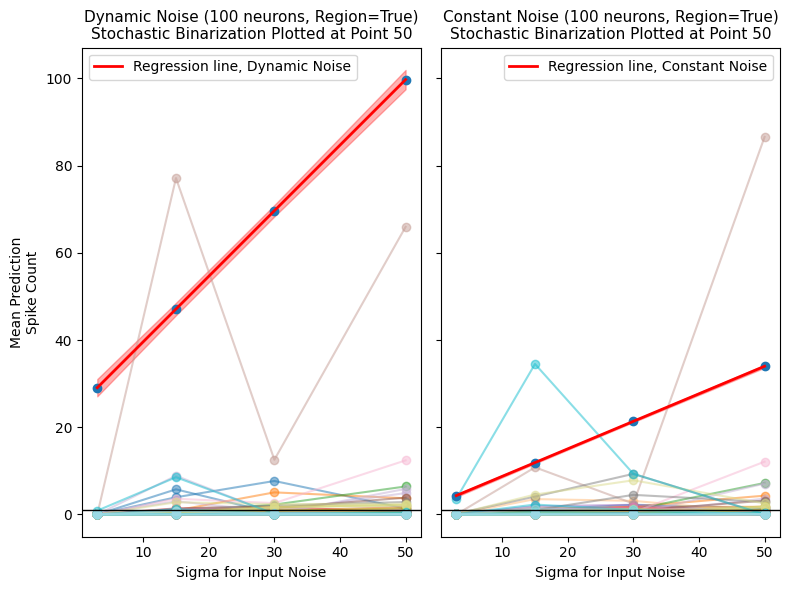

In [64]:
spike_plot(dynamic_arrays_r1_var, constant_arrays_r1_var, False, True, 1)

region 2

In [65]:
dynamic_arrays_r2_var = [plot_var_d3_r2, plot_var_d15_r2, plot_var_d30_r2, plot_var_dbin_r2]
constant_arrays_r2_var = [plot_var_c3_r2, plot_var_c15_r2, plot_var_c30_r2, plot_var_cbin_r2]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-1.936, 4.689]
Constant Noise 95% Confidence Interval for Slope: [-1.546, 3.482


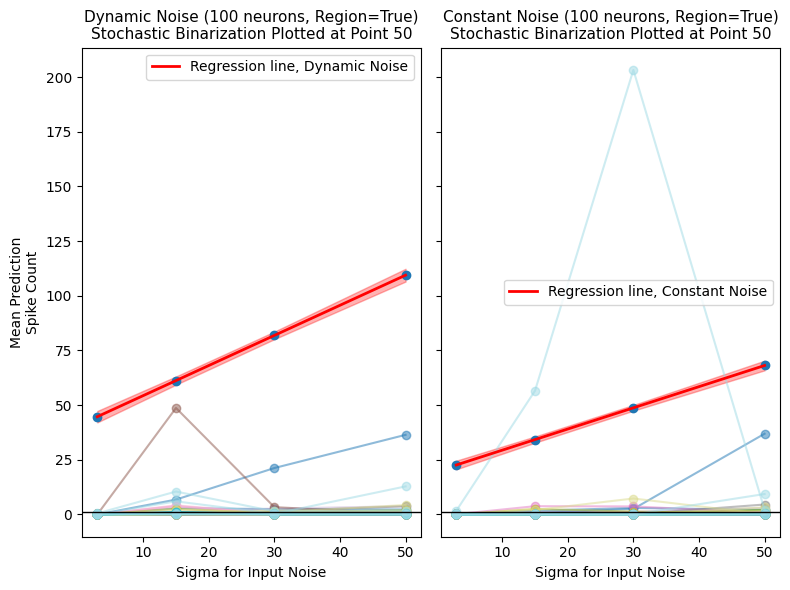

In [66]:
spike_plot(dynamic_arrays_r2_var, constant_arrays_r2_var, False, True, 2)

region 3

In [67]:
dynamic_arrays_r3_var = [plot_var_d3_r3, plot_var_d15_r3, plot_var_d30_r3, plot_var_dbin_r3]
constant_arrays_r3_var = [plot_var_c3_r3, plot_var_c15_r3, plot_var_c30_r3, plot_var_cbin_r3]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [1.148, 3.847]
Constant Noise 95% Confidence Interval for Slope: [0.558, 2.250


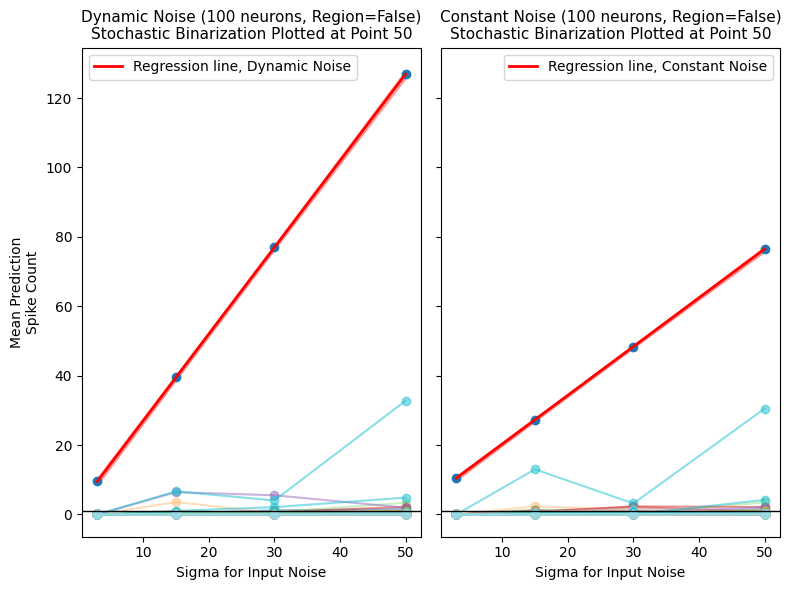

In [68]:
spike_plot(dynamic_arrays_r3_var, constant_arrays_r3_var, False, False, 3)

region 4

In [69]:
dynamic_arrays_r4_var = [plot_var_d3_r4, plot_var_d15_r4, plot_var_d30_r4, plot_var_dbin_r4]
constant_arrays_r4_var = [plot_var_c3_r4, plot_var_c15_r4, plot_var_c30_r4, plot_var_cbin_r4]

C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_61408\2741793010.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


Dynamic Noise 95% Confidence Interval for Slope: [-0.023, 1.084]
Constant Noise 95% Confidence Interval for Slope: [0.307, 0.795


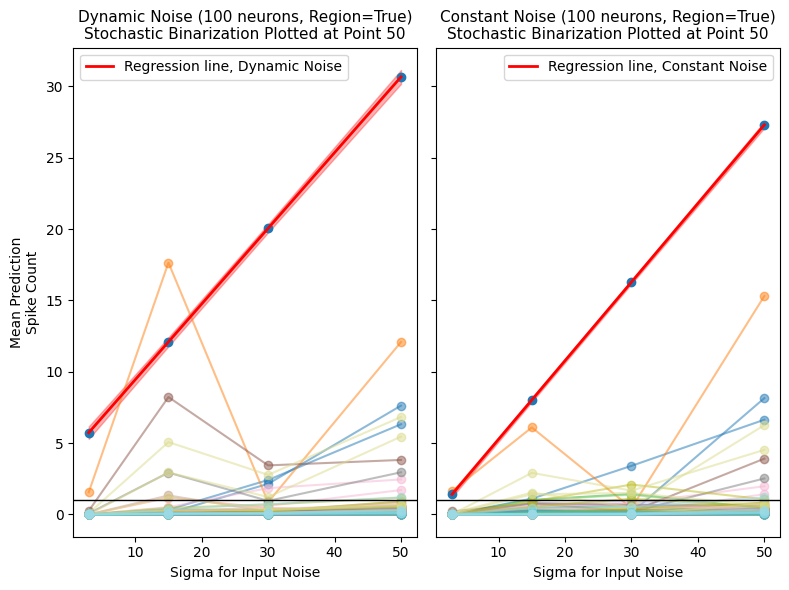

In [70]:
spike_plot(dynamic_arrays_r4_var, constant_arrays_r4_var, False, True, 4)

#### 4x2 plot - var

In [27]:
dynamic_4x2_var = [[plot_var_d3_r1, plot_var_d15_r1, plot_var_d30_r1],
    [plot_var_d3_r2, plot_var_d15_r2, plot_var_d30_r2],
    [plot_var_d3_r3, plot_var_d15_r3, plot_var_d30_r3],
    [plot_var_d3_r4, plot_var_d15_r4, plot_var_d30_r4]]

In [26]:
constant_4x2_var = [[plot_var_c3_r1, plot_var_c15_r1, plot_var_c30_r1],
    [plot_var_c3_r2, plot_var_c15_r2, plot_var_c30_r2],
    [plot_var_c3_r3, plot_var_c15_r3, plot_var_c30_r3],
    [plot_var_c3_r4, plot_var_c15_r4, plot_var_c30_r4]]

In [16]:
np.max(constant_4x2_var[0][0])

np.float64(0.009051636290753246)

In [17]:
constant_4x2_var = [[remove_x(arr[i], 'top', 5) for i in range(3)] for arr in constant_4x2_var]

In [18]:
np.max(constant_4x2_var[0][0])

np.float64(0.003209463912601569)

In [19]:
len(constant_4x2_var[0][0])

95

In [ ]:
def spike_plot_4x2(dynamic_array: list, constant_array: list, mean_plot: bool, 
                   normalized: bool, sigmas: list = [3, 15, 30], num_regions: int = 4):
    """
    Parameters
    ----------
    dynamic_array: list
        List of lists where each sublist contains arrays of mean/var spike counts 
        for different sigmas across neurons for a region
    constant_array: list
        List of lists where each sublist contains arrays of mean/var spike counts 
        for different sigmas across neurons for a region
    mean_plot: bool
        If True, plot mean spike counts; if False, plot variance
    normalized: bool
        If True, normalize values by the response at the first sigma
    sigmas: list
        List of sigma values for noise, defaults to [3, 15, 30]
    num_neurons: int
        Number of neurons to plot, defaults to 100
    num_regions: int
        Number of brain regions from data, defaults to 4
    
    Returns
    -------
    matplotlib plot
        4x2 grid of line plots, each row for a region, with dynamic noise in column 0 
        and constant noise in column 1
    """
    fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex=True)
    sigmas = np.array(sigmas)
    num_neurons = len(dynamic_array[0][0]) # take first array as example for number neurons
    colors = plt.cm.tab20(np.linspace(0, 1, num_neurons))

    for region in range(num_regions):
        ax_dyn = axes[region, 0]
        ax_con = axes[region, 1]
        dynamic_data = dynamic_array[region]  # List of arrays for sigmas in this region
        constant_data = constant_array[region]

        # Dynamic noise plot
        dynamic_means_y = np.empty((num_neurons, len(sigmas)))
        for i in range(num_neurons):
            dynamic_y = np.array([dynamic_data[s_idx][i] for s_idx in range(len(sigmas))])
            if normalized and dynamic_data[0][i] != 0:
                dynamic_y = dynamic_y / dynamic_data[0][i]
            dynamic_means_y[i] = dynamic_y
            ax_dyn.plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color=colors[i])

        dynamic_mean_plot = np.mean(dynamic_means_y, axis=0)
        slope_dyn, intercept_dyn, _, _, std_err_dyn = linregress(sigmas, dynamic_mean_plot)
        y_pred_dyn = intercept_dyn + slope_dyn * sigmas
        ax_dyn.plot(sigmas, y_pred_dyn, 'r-', label='Regression line', linewidth=2)
        dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
        ax_dyn.fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red', alpha=0.3)
        print(f"Region {region}, Dynamic Noise 95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]")
        if not normalized:
            ax_dyn.text(0.05, 0.8, f'Slope: {slope_dyn:.3f}', transform=ax_dyn.transAxes, ha='left', va='top')
        if normalized:
            ax_dyn.axhline(y=1, color='black', linestyle='-', linewidth=1)
        ax_dyn.set_title(f'Dynamic Noise, Region {region}' + 
                         (f'\nNormalized by Response at Sigma={sigmas[0]}' if normalized else ''), 
                         fontsize=11) if region == 0 else ''

        # Constant noise plot
        constant_means_y = np.empty((num_neurons, len(sigmas)))
        for i in range(num_neurons):
            #print(f'i of {i}')
            constant_y = np.array([constant_data[s_idx][i] for s_idx in range(len(sigmas))])
            if normalized and constant_data[0][i] != 0:
                constant_y = constant_y / constant_data[0][i]
            constant_means_y[i] = constant_y
            ax_con.plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color=colors[i])

        constant_mean_plot = np.mean(constant_means_y, axis=0)
        slope_con, intercept_con, _, _, std_err_con = linregress(sigmas, constant_mean_plot)
        y_pred_con = intercept_con + slope_con * sigmas
        ax_con.plot(sigmas, y_pred_con, 'r-', label='Regression line', linewidth=2)
        con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
        ax_con.fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha=0.3)
        print(f"Region {region+1}, Constant Noise 95% CI for Slope: [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]")
        if not normalized:
            ax_con.text(0.05, 0.8, f'Slope: {slope_con:.3f}', transform=ax_con.transAxes, ha='left', va='top')
        if normalized:
            ax_con.axhline(y=1, color='black', linestyle='-', linewidth=1)
        ax_con.set_title(f'Constant Noise' + 
                         (f'\nNormalized by Response at Sigma={sigmas[0]}' if normalized else ''), 
                         fontsize=11) if region == 0 else ''

        # Y-axis label for each region (left column only)
        ax_dyn.set_ylabel(f'Mean Prediction\nSpike Count\n(Region {region+1})' if mean_plot else f'Variance in\nPredicted Spike Count\n(Region {region+1})')

    # X-axis labels for bottom row only
    axes[3, 0].set_xlabel('Sigma for Input Noise')
    axes[3, 1].set_xlabel('Sigma for Input Noise')

    # Add legend to each subplot
    for ax in axes.flat:
        ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

Region 0, Dynamic Noise 95% CI for Slope: [0.001, 0.005]
i of 0
i of 1
i of 2
i of 3
i of 4
i of 5
i of 6
i of 7
i of 8
i of 9
i of 10
i of 11
i of 12
i of 13
i of 14
i of 15
i of 16
i of 17
i of 18
i of 19
i of 20
i of 21
i of 22
i of 23
i of 24
i of 25
i of 26
i of 27
i of 28
i of 29
i of 30
i of 31
i of 32
i of 33
i of 34
i of 35
i of 36
i of 37
i of 38
i of 39
i of 40
i of 41
i of 42
i of 43
i of 44
i of 45
i of 46
i of 47
i of 48
i of 49
i of 50
i of 51
i of 52
i of 53
i of 54
i of 55
i of 56
i of 57
i of 58
i of 59
i of 60
i of 61
i of 62
i of 63
i of 64
i of 65
i of 66
i of 67
i of 68
i of 69
i of 70
i of 71
i of 72
i of 73
i of 74
i of 75
i of 76
i of 77
i of 78
i of 79
i of 80
i of 81
i of 82
i of 83
i of 84
i of 85
i of 86
i of 87
i of 88
i of 89
i of 90
i of 91
i of 92
i of 93
i of 94
i of 95
i of 96
i of 97
i of 98
i of 99
Region 1, Constant Noise 95% CI for Slope: [0.004, 0.013]
Region 1, Dynamic Noise 95% CI for Slope: [0.002, 0.007]
i of 0
i of 1
i of 2
i of 3
i of 4
i o

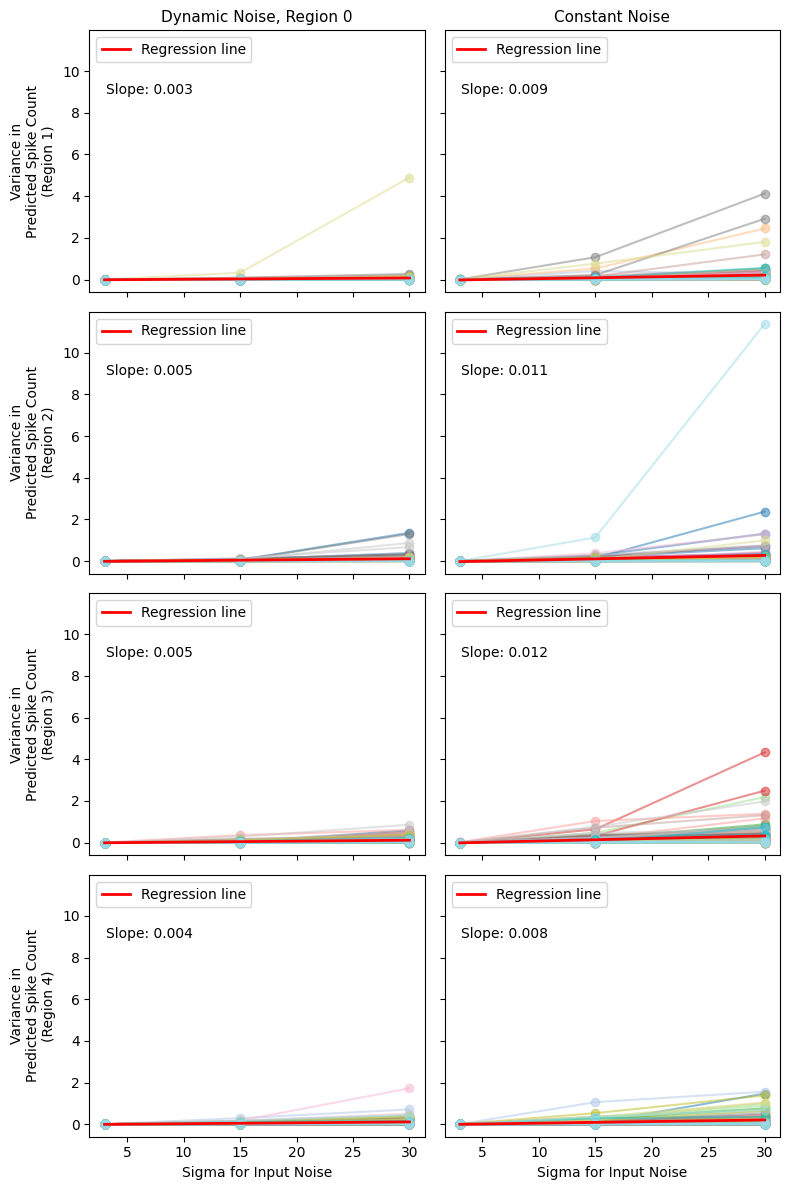

In [29]:
spike_plot_4x2(dynamic_4x2_var, constant_4x2_var, False, False)

#### filtering out sum data

In [76]:
def filter_region(region_input: int, num_images: int, label_mapping, array):
    """
    Parameters
    ----------
    region_input: int
        specified region to output
    num_images: int
        number of images used for predict_loop()
    label_mapping: label
        mapping output from scans()
    array: np.array
        array to filter

    Returns
    -------
    array
        filtered array where brain region is equal to region_input
    """
    if (array.ndim == 3): label_mapping = np.repeat(label_mapping[:, np.newaxis, :], array.shape[1], axis = 1)
    concat_array = np.concatenate((array, label_mapping), axis=0)
    region_indices = np.where(concat_array[num_images] == region_input)
    return array[..., region_indices[0]]

In [87]:
d3_sum.shape

(5, 100, 7493)

In [88]:
d3_labels.shape

(1, 7493)

In [89]:
d3_labels_test = np.repeat(d3_labels[:, np.newaxis, :], d3_sum.shape[1], axis = 1)

In [90]:
d3_labels_test.shape

(1, 100, 7493)

In [91]:
concat = np.concatenate([d3_sum, d3_labels_test], axis = 0)

In [92]:
concat.shape

(6, 100, 7493)

In [93]:
test_filter = np.where(concat[5] == 4)[0]

In [94]:
test_filter.shape

(81100,)

In [86]:
d3_sum[..., test_filter].shape

(5, 100, 81100)

NOTE: issue is with concatenating here, adds too many new neuron instances

dynamic data

In [ ]:
d3_sum_r1 = filter_region(1, 5, d3_labels, d3_sum)
d15_sum_r1 = filter_region(1, 5, d15_labels, d15_sum)
d30_sum_r1 = filter_region(1, 5, d30_labels, d30_sum)
dbin_sum_r1 = filter_region(1, 5, dbin_labels, dbin_sum)

MemoryError: Unable to allocate 1.98 GiB for an array with shape (531200, 5, 100) and data type float64

In [62]:
d3_sum_r2 = filter_region(2, 5, d3_labels, d3_sum)
d15_sum_r2 = filter_region(2, 5, d15_labels, d15_sum)
d30_sum_r2 = filter_region(2, 5, d30_labels, d30_sum)
dbin_sum_r2 = filter_region(2, 5, dbin_labels, dbin_sum)

In [24]:
d3_sum_r3 = filter_region(3, 5, d3_labels, d3_sum)
d15_sum_r3 = filter_region(3, 5, d15_labels, d15_sum)
d30_sum_r3 = filter_region(3, 5, d30_labels, d30_sum)
dbin_sum_r3 = filter_region(3, 5, dbin_labels, dbin_sum)

In [25]:
d3_sum_r4 = filter_region(4, 5, d3_labels, d3_sum)
d15_sum_r4 = filter_region(4, 5, d15_labels, d15_sum)
d30_sum_r4 = filter_region(4, 5, d30_labels, d30_sum)
dbin_sum_r4 = filter_region(4, 5, dbin_labels, dbin_sum)

constant data

In [26]:
c3_sum_r1 = filter_region(1, 5, c3_labels, c3_sum)
c15_sum_r1 = filter_region(1, 5, c15_labels, c15_sum)
c30_sum_r1 = filter_region(1, 5, c30_labels, c30_sum)
cbin_sum_r1 = filter_region(1, 5, cbin_labels, cbin_sum)

In [27]:
c3_sum_r2 = filter_region(2, 5, c3_labels, c3_sum)
c15_sum_r2 = filter_region(2, 5, c15_labels, c15_sum)
c30_sum_r2 = filter_region(2, 5, c30_labels, c30_sum)
cbin_sum_r2 = filter_region(2, 5, cbin_labels, cbin_sum)

In [28]:
c3_sum_r3 = filter_region(3, 5, c3_labels, c3_sum)
c15_sum_r3 = filter_region(3, 5, c15_labels, c15_sum)
c30_sum_r3 = filter_region(3, 5, c30_labels, c30_sum)
cbin_sum_r3 = filter_region(3, 5, cbin_labels, cbin_sum)

In [29]:
c3_sum_r4 = filter_region(4, 5, c3_labels, c3_sum)
c15_sum_r4 = filter_region(4, 5, c15_labels, c15_sum)
c30_sum_r4 = filter_region(4, 5, c30_labels, c30_sum)
cbin_sum_r4 = filter_region(4, 5, cbin_labels, cbin_sum)

#### no noise filtering

In [30]:
no_noise_sum_r1 = filter_region(1, 5, no_noise_labels, no_noise_sum)
no_noise_sum_r2 = filter_region(2, 5, no_noise_labels, no_noise_sum)
no_noise_sum_r3 = filter_region(3, 5, no_noise_labels, no_noise_sum)
no_noise_sum_r4 = filter_region(4, 5, no_noise_labels, no_noise_sum)

#### turning curves

dynamic noise

In [34]:
no_noise_sum_r1.shape

(5, 100, 531200)

In [36]:
d3_sum_r1.shape

(5, 100, 531200)

In [37]:
dbin_sum_r1.shape

(5, 100, 531200)

In [31]:
d5arrays_r1 = [no_noise_sum_r1, d3_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1]
dr1_titles = ['Region 1\n \nNo Noise', 'Dynamic Noise, Sigma = 3', 'Dynamic Noise, Sigma = 15', 
          'Dynamic Noise, Sigma = 30', 'Dynamic\nStochastic Binarization']

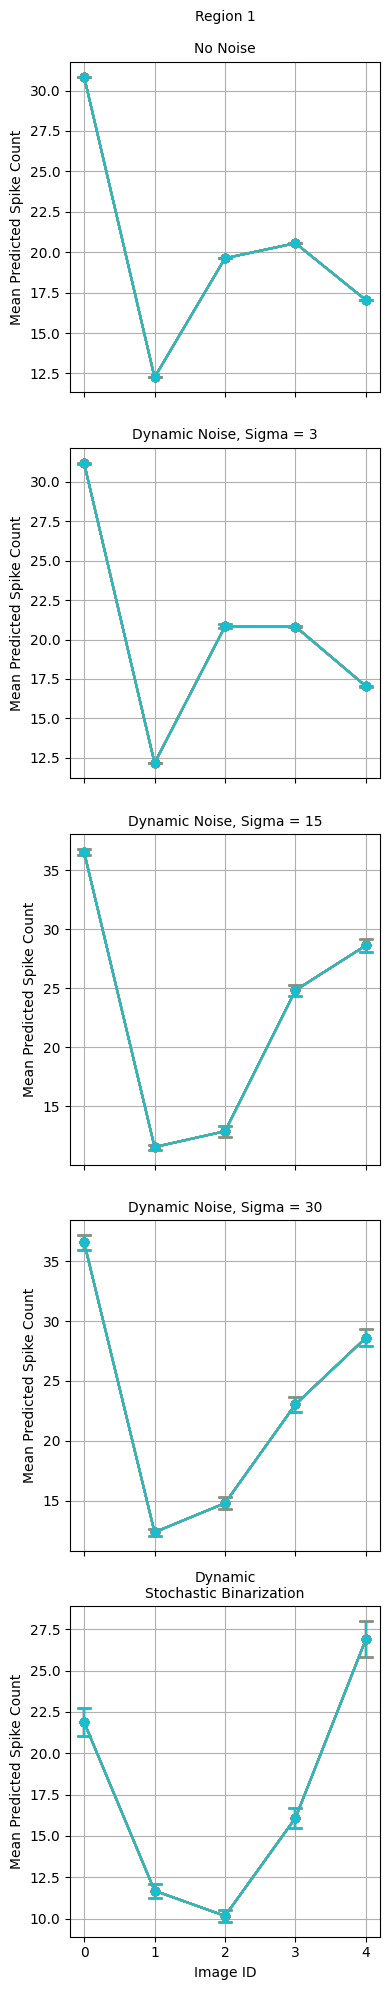

In [33]:
five_turning_curves(d5arrays_r1, dr1_titles)

#### mean var plots
plots 1

region 1

In [126]:
def mean_var_scatter_2x2(plot_title: str, means, vars, titles, remove_x_str: str = None, x_percent: int = None):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, plot_title, ha='center', va='top', fontsize=12, 
             fontweight = 'bold', bbox=dict(facecolor='white'))
    for i in range(2):
        for j in range(2):
            idx = i * 2 + j
            ax = axes[i, j]

            region_mean = means[idx].flatten()
            region_var = vars[idx].flatten()
            
            if remove_x_str is not None and x_percent is not None:                  
                x = remove_x(region_mean, remove_x_str, x_percent)
                y = remove_x(region_var, remove_x_str, x_percent)
            else:
                x = region_mean
                y = region_var
            cmap = plt.get_cmap('viridis')
            colors = cmap(np.linspace(0, 1, len(x)))
            ax.scatter(x, y, marker='^', color = colors)

            linregress_result = linregress(region_mean, region_var)
            x_fit = np.linspace(np.min(x), np.max(x), 100)
            y_fit = linregress_result.intercept + linregress_result.slope * x_fit

            ax.plot(x_fit, y_fit, color='red', label='Regression line', linewidth=2)

            se_fit = linregress_result.stderr * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
            ax.fill_between(x_fit, y_fit - 1.96 * se_fit, y_fit + 1.96 * se_fit, color='gray', alpha=0.7, label='95% CI')

            
            rsq = linregress_result.rvalue ** 2
            y_subtract = 100 if np.max(y) > 500 else .05
            ax.text(1, np.max(y) - y_subtract, f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.slope:.3f},"
                    f"{linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
                    fontsize=8, verticalalignment='top')
            
            ax.set_title(titles[idx])
            ax.grid(True)
            ax.legend()
            ax.set_ylim(0,np.max(y))
            ax.set_xlim(0,np.max(x))
            if i == 1: ax.set_xlabel('Mean Predicted Spike Count')
            if j == 0: ax.set_ylabel('Variance in Predicted Spike Count')
    
    plt.tight_layout()
    plt.show()

In [127]:
region1_means = [d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1]
region1_var = [d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1]
region1_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

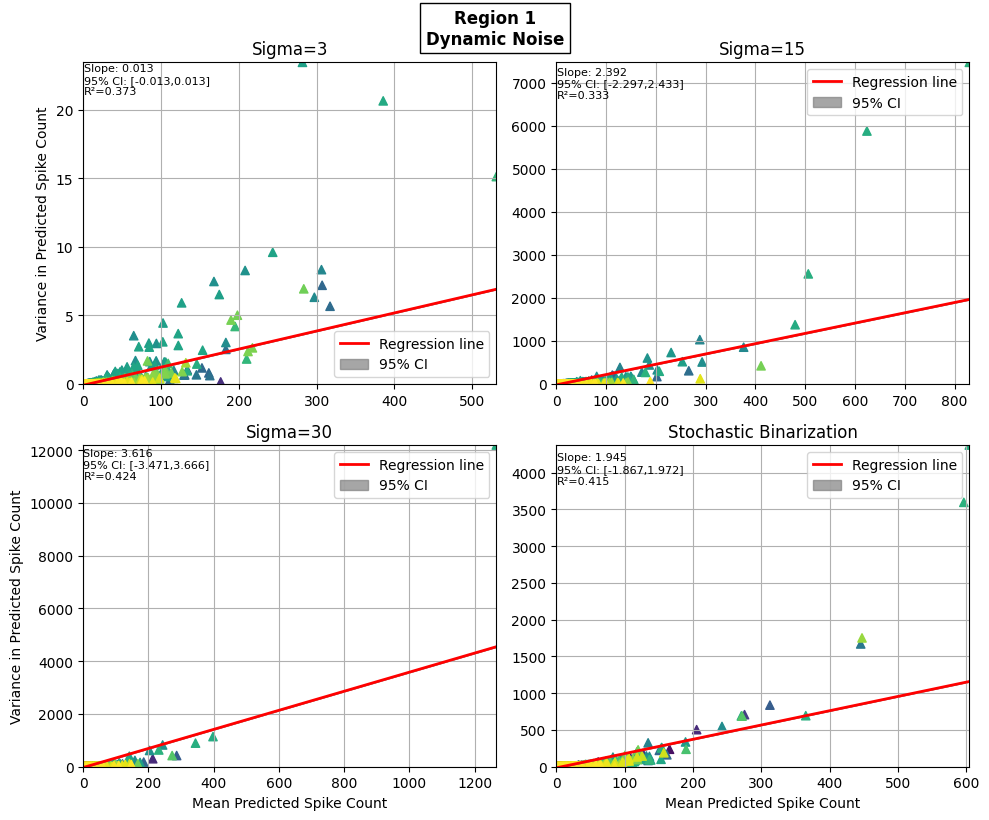

In [128]:
mean_var_scatter_2x2('Region 1\nDynamic Noise',region1_means, region1_var, region1_titles, 'top', 10)

In [129]:
region1_means = [c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1]
region1_var = [c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1]
region1_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

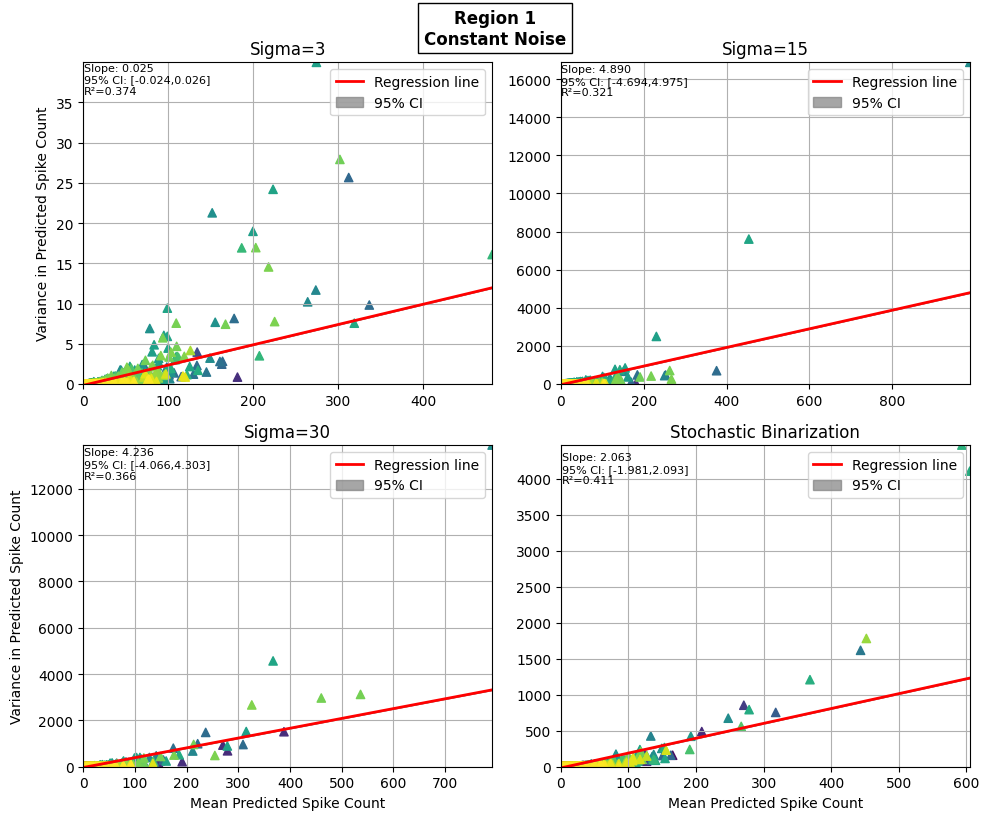

In [130]:
mean_var_scatter_2x2('Region 1\nConstant Noise',region1_means, region1_var, region1_titles, 'top', 10)

In [131]:
region2_means = [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2]
region2_var = [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2]
region2_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

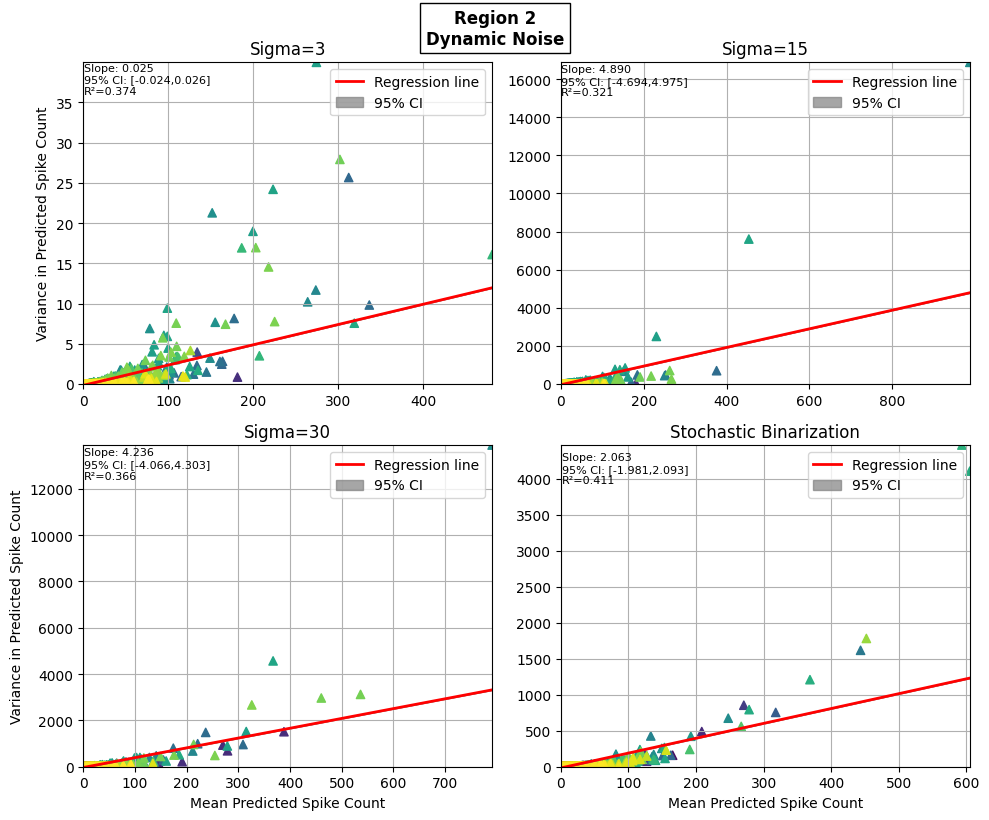

In [132]:
mean_var_scatter_2x2('Region 2\nDynamic Noise',region1_means, region1_var, region1_titles, 'top', 10)

In [133]:
region2_means = [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2]
region2_var = [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2]
region2_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

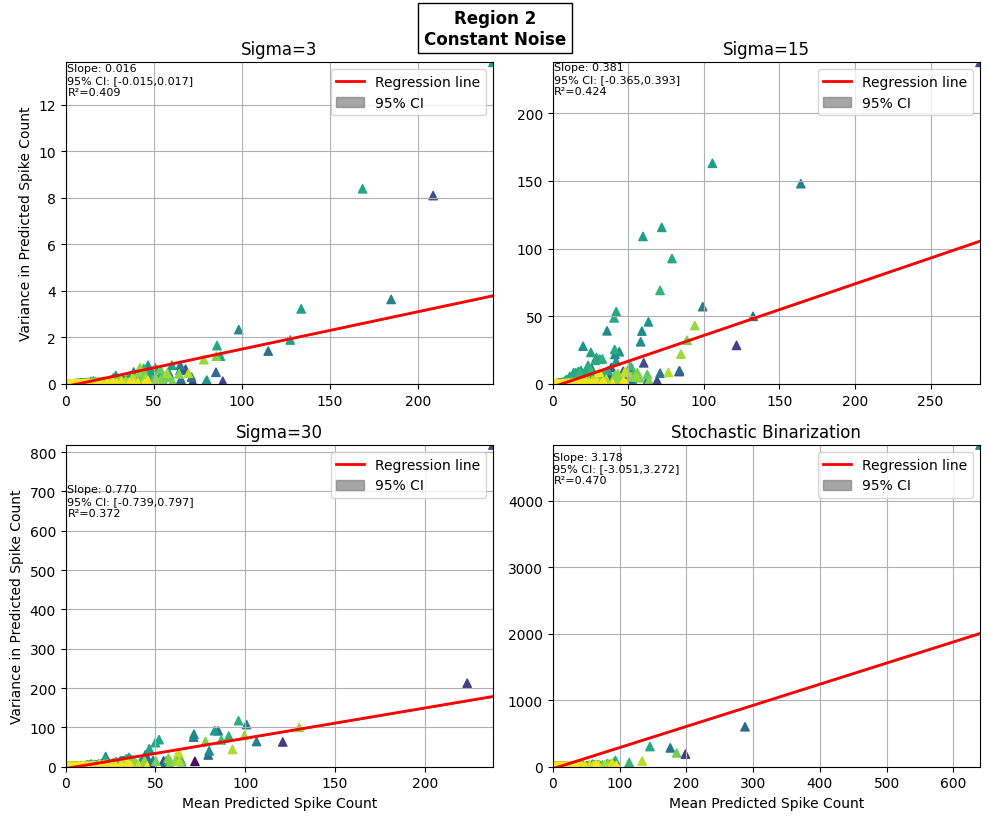

In [134]:
mean_var_scatter_2x2('Region 2\nConstant Noise',region2_means, region2_var, region2_titles, 'top', 10)

In [135]:
region3_means = [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3]
region3_var = [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3]
region3_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

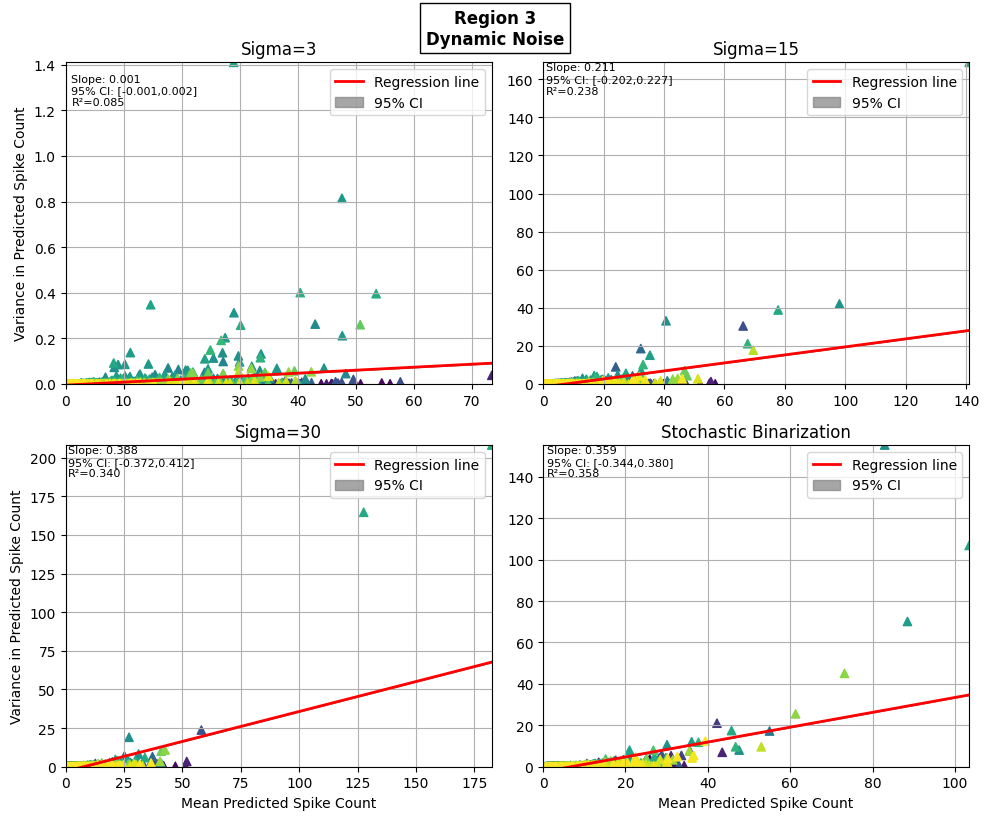

In [136]:
mean_var_scatter_2x2('Region 3\nDynamic Noise',region3_means, region3_var, region3_titles, 'top', 10)

In [137]:
region3_means = [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3]
region3_var = [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3]
region3_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

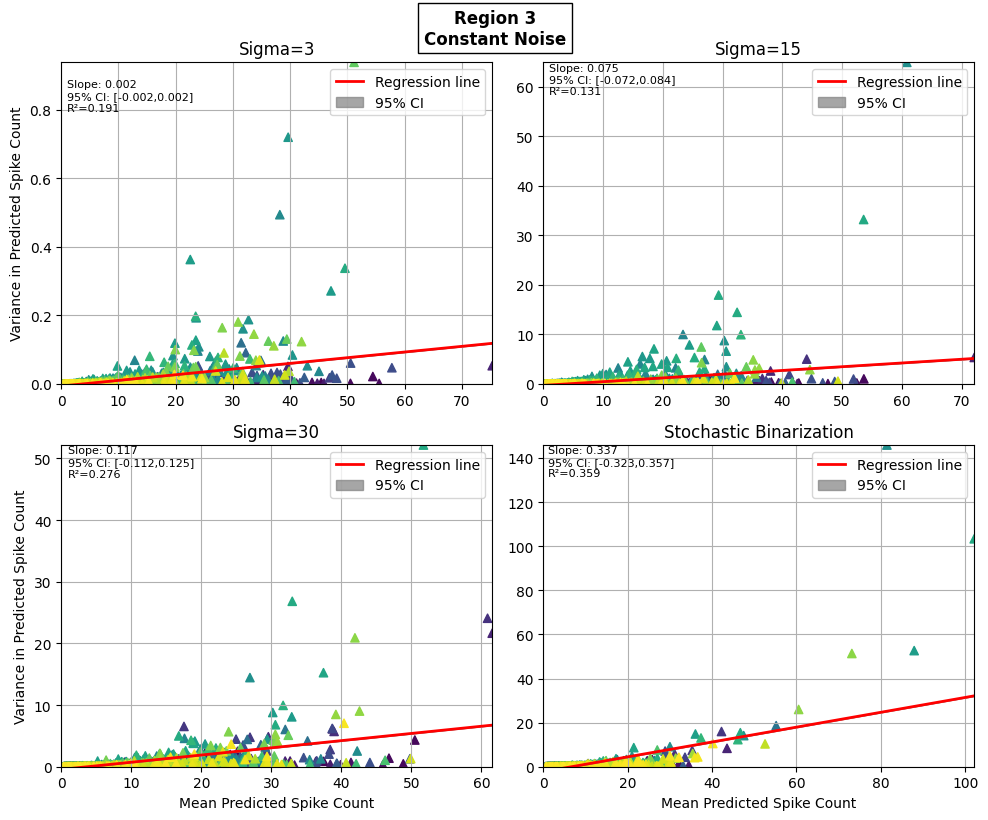

In [139]:
mean_var_scatter_2x2('Region 3\nConstant Noise',region3_means, region3_var, region3_titles, 'top', 10)

In [140]:
region4_means = [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]
region4_var = [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]
region4_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

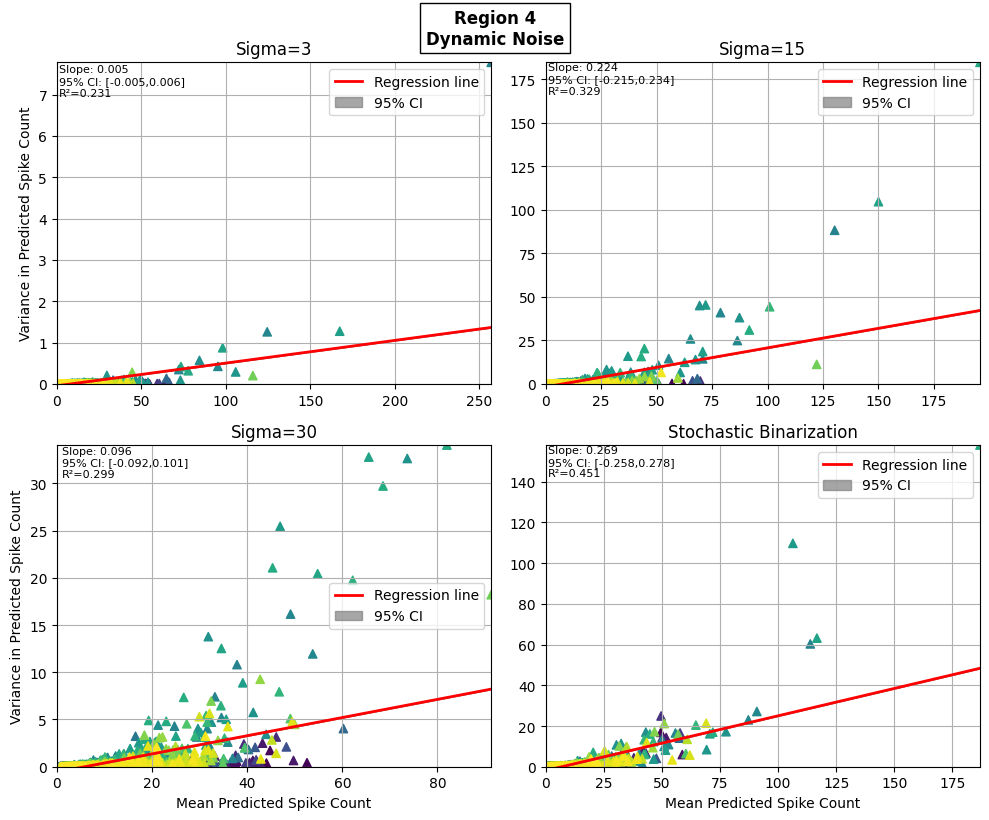

In [141]:
mean_var_scatter_2x2('Region 4\nDynamic Noise',region4_means, region4_var, region4_titles, 'top', 10)

In [142]:
region4_means = [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]
region4_var = [d3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]
region4_titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

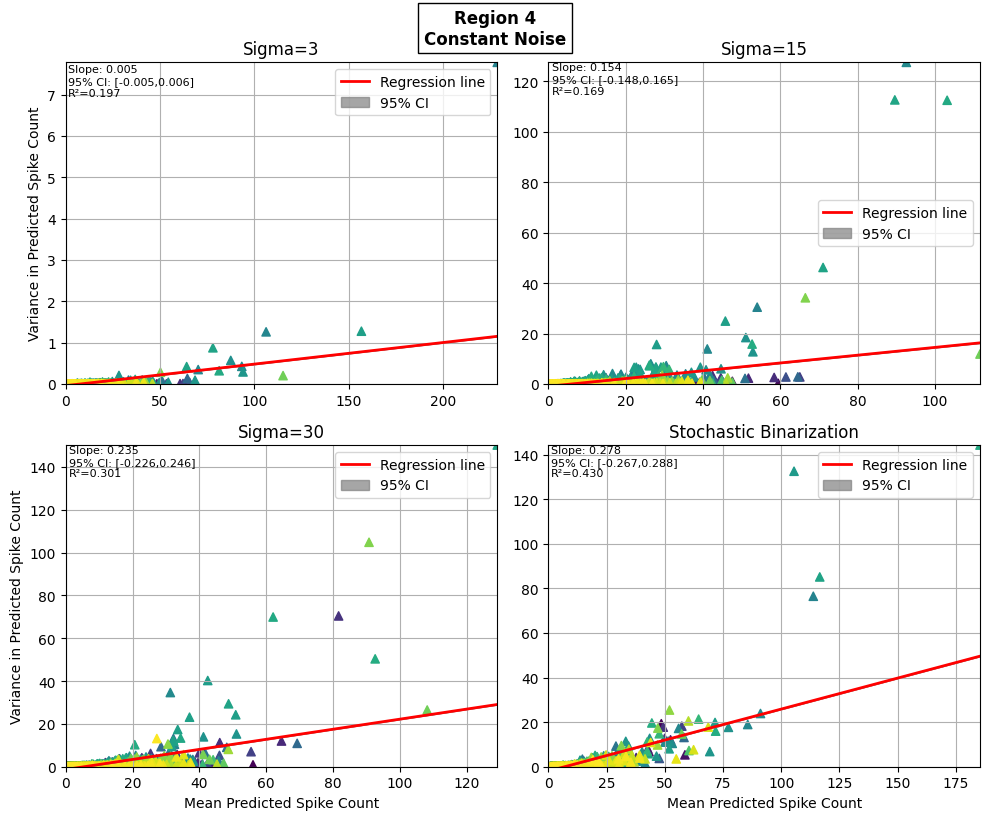

In [143]:
mean_var_scatter_2x2('Region 4\nConstant Noise',region4_means, region4_var, region4_titles, 'top', 10)